## 11.2. Attention Pooling by Similarity

In [1]:
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

d2l.use_svg_display()

### 11.2.1. Kernels and Data

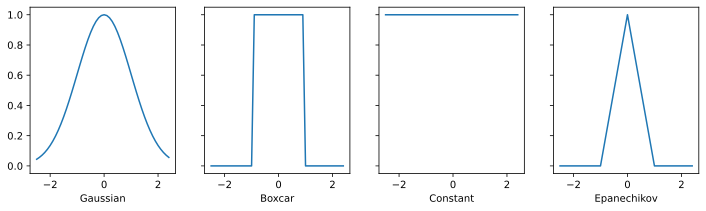

In [2]:
# Define some kernels
def gaussian(x):
    return torch.exp(-x**2 / 2)

def boxcar(x):
    return torch.abs(x) < 1.0

def constant(x):
    return 1.0 + 0 * x

def epanechikov(x):
    return torch.max(1 - torch.abs(x), torch.zeros_like(x))

fig, axes = d2l.plt.subplots(1, 4, sharey=True, figsize=(12, 3))

kernels = (gaussian, boxcar, constant, epanechikov)
names = ('Gaussian', 'Boxcar', 'Constant', 'Epanechikov')
x = torch.arange(-2.5, 2.5, 0.1)
for kernel, name, ax in zip(kernels, names, axes):
    ax.plot(x.detach().numpy(), kernel(x).detach().numpy())
    ax.set_xlabel(name)

d2l.plt.show()

In [8]:
x, boxcar(x)

(tensor([-2.5000e+00, -2.4000e+00, -2.3000e+00, -2.2000e+00, -2.1000e+00,
         -2.0000e+00, -1.9000e+00, -1.8000e+00, -1.7000e+00, -1.6000e+00,
         -1.5000e+00, -1.4000e+00, -1.3000e+00, -1.2000e+00, -1.1000e+00,
         -1.0000e+00, -9.0000e-01, -8.0000e-01, -7.0000e-01, -6.0000e-01,
         -5.0000e-01, -4.0000e-01, -3.0000e-01, -2.0000e-01, -1.0000e-01,
         -1.4901e-09,  1.0000e-01,  2.0000e-01,  3.0000e-01,  4.0000e-01,
          5.0000e-01,  6.0000e-01,  7.0000e-01,  8.0000e-01,  9.0000e-01,
          1.0000e+00,  1.1000e+00,  1.2000e+00,  1.3000e+00,  1.4000e+00,
          1.5000e+00,  1.6000e+00,  1.7000e+00,  1.8000e+00,  1.9000e+00,
          2.0000e+00,  2.1000e+00,  2.2000e+00,  2.3000e+00,  2.4000e+00]),
 tensor([False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True

In [81]:
def f(x):
    return 2 * torch.sin(x) + x

n = 40
x_train, _ = torch.sort(torch.rand(n) * 5)
y_train = f(x_train) + torch.randn(n)
x_val = torch.arange(0, 5, 0.1)
y_val = f(x_val)

In [22]:
torch.randn(40)

tensor([-0.1061, -0.3655,  1.3218, -0.0563,  0.9205,  0.7486,  2.0994,  0.3566,
        -0.4071,  1.2882,  0.9559,  0.4998,  0.6866, -1.0055, -0.5907,  0.0518,
         0.5686, -0.8980, -0.7258, -0.6996,  1.0601, -0.3858, -0.6585,  0.0664,
        -0.3137,  0.7579,  0.3330, -1.3377,  0.2951, -0.5357,  0.9658, -0.3271,
         0.1434, -0.5798,  1.6291,  0.3295,  1.1780, -1.0947, -0.3102,  0.7603])

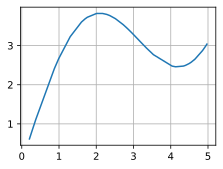

In [37]:
d2l.plot(x_train.detach().numpy(), f(x_train).detach().numpy())

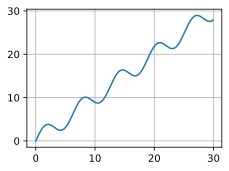

In [19]:
d2l.plot(torch.arange(0, 30, 0.1), f(torch.arange(0, 30, 0.1)))

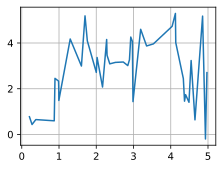

In [16]:
d2l.plot(x_train.detach().numpy(), y_train.detach().numpy())

### 11.2.2. Attention Pooling via Nadaraya–Watson Regression

In [79]:
def nadaraya_watson_test(x_train, y_train, x_val, kernel):
    dists = x_train.reshape((-1, 1)) - x_val.reshape((1, -1))
    print(dists.shape, dists[1], '\n')
    # Each column/row corresponds to each query/key
    k = kernel(dists).type(torch.float32)
    print(k.shape, k[1], '\n')
    # Normalization over keys for each query
    attention_w = k / k.sum(0)
    print(attention_w.shape, attention_w[1], '\n')
    y_hat = y_train@attention_w
    print(y_hat.shape, y_hat[1], '\n')
    return y_hat, attention_w

In [78]:
x_train.shape, x_train[:5], x_train.reshape(-1, 1).shape, x_train.reshape(-1, 1)[:5]

(torch.Size([40]),
 tensor([0.2059, 0.2760, 0.3775, 0.8718, 0.8920]),
 torch.Size([40, 1]),
 tensor([[0.2059],
         [0.2760],
         [0.3775],
         [0.8718],
         [0.8920]]))

In [70]:
x_val.shape, x_val[:5], x_val.reshape(1, -1).shape, x_val.reshape(1, -1)[:5]

(torch.Size([50]),
 tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000]),
 torch.Size([1, 50]),
 tensor([[0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
          0.9000, 1.0000, 1.1000, 1.2000, 1.3000, 1.4000, 1.5000, 1.6000, 1.7000,
          1.8000, 1.9000, 2.0000, 2.1000, 2.2000, 2.3000, 2.4000, 2.5000, 2.6000,
          2.7000, 2.8000, 2.9000, 3.0000, 3.1000, 3.2000, 3.3000, 3.4000, 3.5000,
          3.6000, 3.7000, 3.8000, 3.9000, 4.0000, 4.1000, 4.2000, 4.3000, 4.4000,
          4.5000, 4.6000, 4.7000, 4.8000, 4.9000]]))

In [73]:
(x_train.reshape((-1, 1)) - x_val.reshape((1, -1))).shape, (x_train.reshape((-1, 1)) - x_val.reshape((1, -1)))[:5]

(torch.Size([40, 50]),
 tensor([[ 0.2059,  0.1059,  0.0059, -0.0941, -0.1941, -0.2941, -0.3941, -0.4941,
          -0.5941, -0.6941, -0.7941, -0.8941, -0.9941, -1.0941, -1.1941, -1.2941,
          -1.3941, -1.4941, -1.5941, -1.6941, -1.7941, -1.8941, -1.9941, -2.0941,
          -2.1941, -2.2941, -2.3941, -2.4941, -2.5941, -2.6941, -2.7941, -2.8941,
          -2.9941, -3.0941, -3.1941, -3.2941, -3.3941, -3.4941, -3.5941, -3.6941,
          -3.7941, -3.8941, -3.9941, -4.0941, -4.1941, -4.2941, -4.3941, -4.4941,
          -4.5941, -4.6941],
         [ 0.2760,  0.1760,  0.0760, -0.0240, -0.1240, -0.2240, -0.3240, -0.4240,
          -0.5240, -0.6240, -0.7240, -0.8240, -0.9240, -1.0240, -1.1240, -1.2240,
          -1.3240, -1.4240, -1.5240, -1.6240, -1.7240, -1.8240, -1.9240, -2.0240,
          -2.1240, -2.2240, -2.3240, -2.4240, -2.5240, -2.6240, -2.7240, -2.8240,
          -2.9240, -3.0240, -3.1240, -3.2240, -3.3240, -3.4240, -3.5240, -3.6240,
          -3.7240, -3.8240, -3.9240, -4.0240, 

In [74]:
y_train.shape, y_train[:5]

(torch.Size([40]), tensor([0.7744, 0.4339, 0.6499, 0.5960, 2.4534]))

In [64]:
nadaraya_watson_test(x_train, y_train, x_val, gaussian)

torch.Size([40, 50]) tensor([ 0.2760,  0.1760,  0.0760, -0.0240, -0.1240, -0.2240, -0.3240, -0.4240,
        -0.5240, -0.6240, -0.7240, -0.8240, -0.9240, -1.0240, -1.1240, -1.2240,
        -1.3240, -1.4240, -1.5240, -1.6240, -1.7240, -1.8240, -1.9240, -2.0240,
        -2.1240, -2.2240, -2.3240, -2.4240, -2.5240, -2.6240, -2.7240, -2.8240,
        -2.9240, -3.0240, -3.1240, -3.2240, -3.3240, -3.4240, -3.5240, -3.6240,
        -3.7240, -3.8240, -3.9240, -4.0240, -4.1240, -4.2240, -4.3240, -4.4240,
        -4.5240, -4.6240]) 

torch.Size([40, 50]) tensor([9.6263e-01, 9.8463e-01, 9.9712e-01, 9.9971e-01, 9.9234e-01, 9.7522e-01,
        9.4886e-01, 9.1403e-01, 8.7172e-01, 8.2309e-01, 7.6944e-01, 7.1213e-01,
        6.5253e-01, 5.9197e-01, 5.3169e-01, 4.7279e-01, 4.1624e-01, 3.6280e-01,
        3.1308e-01, 2.6748e-01, 2.2625e-01, 1.8947e-01, 1.5709e-01, 1.2895e-01,
        1.0480e-01, 8.4322e-02, 6.7171e-02, 5.2976e-02, 4.1365e-02, 3.1978e-02,
        2.4475e-02, 1.8546e-02, 1.3913e-02, 1.033

(tensor([1.8026, 1.8689, 1.9372, 2.0074, 2.0792, 2.1524, 2.2265, 2.3012, 2.3760,
         2.4505, 2.5241, 2.5964, 2.6668, 2.7349, 2.8003, 2.8625, 2.9212, 2.9762,
         3.0272, 3.0741, 3.1167, 3.1552, 3.1893, 3.2193, 3.2450, 3.2666, 3.2840,
         3.2973, 3.3064, 3.3113, 3.3120, 3.3085, 3.3008, 3.2888, 3.2728, 3.2529,
         3.2292, 3.2022, 3.1722, 3.1396, 3.1049, 3.0685, 3.0310, 2.9927, 2.9542,
         2.9159, 2.8780, 2.8408, 2.8046, 2.7696]),
 tensor([[1.2339e-01, 1.1473e-01, 1.0624e-01,  ..., 2.9297e-06, 1.9594e-06,
          1.3049e-06],
         [1.2132e-01, 1.1360e-01, 1.0593e-01,  ..., 4.0050e-06, 2.6973e-06,
          1.8090e-06],
         [1.1736e-01, 1.1101e-01, 1.0458e-01,  ..., 6.2433e-06, 4.2477e-06,
          2.8778e-06],
         ...,
         [9.6028e-07, 1.4213e-06, 2.0951e-06,  ..., 7.0368e-02, 7.4914e-02,
          7.9417e-02],
         [6.5785e-07, 9.8125e-07, 1.4576e-06,  ..., 6.9323e-02, 7.4374e-02,
          7.9457e-02],
         [5.4167e-07, 8.1113e-07, 1

In [82]:
def nadaraya_watson(x_train, y_train, x_val, kernel):
    dists = x_train.reshape((-1, 1)) - x_val.reshape((1, -1))
    # Each column/row corresponds to each query/key
    k = kernel(dists).type(torch.float32)
    # Normalization over keys for each query
    attention_w = k / k.sum(0)
    y_hat = y_train@attention_w
    return y_hat, attention_w

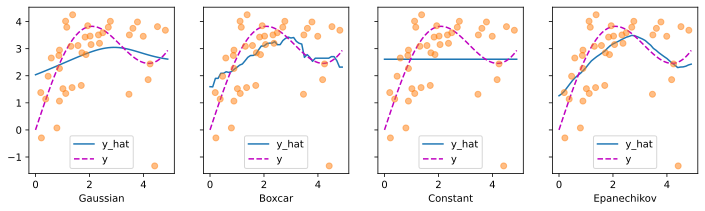

In [83]:
def plot(x_train, y_train, x_val, y_val, kernels, names, attention=False):
    fig, axes = d2l.plt.subplots(1, 4, sharey=True, figsize=(12, 3))
    for kernel, name, ax in zip(kernels, names, axes):
        y_hat, attention_w = nadaraya_watson(x_train, y_train, x_val, kernel)
        if attention:
            pcm = ax.imshow(attention_w.detach().numpy(), cmap='Reds')
        else:
            ax.plot(x_val, y_hat)
            ax.plot(x_val, y_val, 'm--')
            ax.plot(x_train, y_train, 'o', alpha=0.5);
        ax.set_xlabel(name)
        if not attention:
            ax.legend(['y_hat', 'y'])
    if attention:
        fig.colorbar(pcm, ax=axes, shrink=0.7)

plot(x_train, y_train, x_val, y_val, kernels, names)

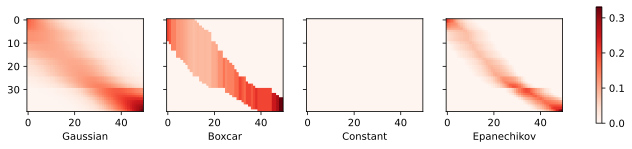

In [84]:
plot(x_train, y_train, x_val, y_val, kernels, names, attention=True)

### 11.2.3. Adapting Attention Pooling

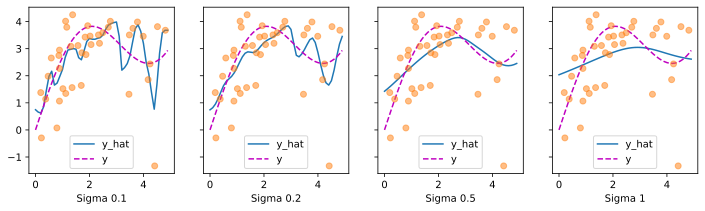

In [88]:
sigmas = (0.1, 0.2, 0.5, 1)
names = ['Sigma ' + str(sigma) for sigma in sigmas]

def gaussian_with_width(sigma):
    return (lambda x: torch.exp(-x**2 / (2*sigma**2)))

kernels = [gaussian_with_width(sigma) for sigma in sigmas]
plot(x_train, y_train, x_val, y_val, kernels, names)

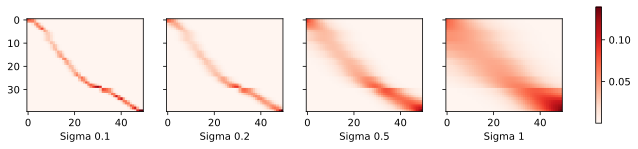

In [90]:
plot(x_train, y_train, x_val, y_val, kernels, names, attention=True)